# 11. Test-statistic distributions and calibration with toys


    Measure the **stat-only** sampling distribution at the two requested
    hypotheses, \(\mu=0\) and \(\mu=1.4\). In each ensemble the tested value is
    also the generating truth. Compare analytical and learned unbinned fits
    with the **direct 12-bin histogram model**, using the same binning method
    as notebook 08, physical simulator toys, and each model's own toys.

    Reuse completed **01–03** in the same v4 run. This notebook integrates
    process yields directly in the bins; it does not use notebook 09's spline
    parametrizations. No training or rerun of earlier notebooks is needed.
    Saved progress makes the toy study resumable. The default output tag
    `toy_study_direct` keeps these results separate from the earlier spline study.

### Reuse the completed v4 run

Keep **`RUN_NAME = "paper-distinct-s-v4"`**, the same `MODE`, and the same
`CONFIG_OVERRIDES` used for your completed notebooks 01–03. This notebook
loads the trained ratios and selected integration bank, then computes the
**12-bin, a=100** process yields directly with the histogram method of
notebook 08. It does not load spline templates or require outputs from 08–10.
For this update, rerun **11 only**; no regeneration or retraining is needed.

Start a fresh Colab runtime to load the updated source. The temporary checkout
is `/content/poodemo`; delete that checkout if reusing a runtime with old source,
then restart. Your saved run in Google Drive is separate. The setup downloads
the repository if needed and mounts Drive. For a private repository, give Colab
read access, save a fine-grained token with repository **Contents: read** access
as the `GITHUB_TOKEN` Colab secret, or use the hidden prompt. Alternatively,
upload `/content/poodemo_source.zip`. Tokens are not printed or saved.

`JAX_BACKEND="auto"` uses a Colab GPU when available. Choose `"cpu"` for an
intentional CPU run or `"gpu"` to require a GPU. Setup verifies double-precision
JAX calculations. `MODE="smoke"` uses a separate, already-created smoke run;
changing this notebook's mode does not create the prerequisite samples/models.
Only a migration from an older, incompatible run requires rerunning 01–03.

In [ ]:
import os
import sys
from pathlib import Path

RUN_NAME = "paper-distinct-s-v4"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))


import mplhep as hep
hep.style.use("ATLAS")
# ATLAS-like typography/ticks only: no experiment label is added.
plt.rcParams.update({"axes.grid": False, "figure.dpi": 110})

### Define one statistic and five comparisons

At each tested \(\mu_0\), use the **two-sided** likelihood-ratio statistic
\[
t_{\mu_0}=-2\log\frac{L(\mu_0)}{L(\widehat\mu)},
\qquad \widehat\mu=\underset{0\leq\mu\leq2}{\arg\max}\ L(\mu).
\]
All NI nuisances are fixed at nominal. This is not the one-sided
upper-limit statistic that sets the result to zero when
\(\widehat\mu>\mu_0\). The exact zero boundary is included: minimization
uses \(\kappa=\sqrt\mu\), avoiding differentiation of \(\sqrt\mu\) at zero,
and searches the grid's candidate minima before local refinement.
The point 1.4 lies inside the fit range, allowing fluctuations on both
sides. Inspect upper-bound fits before trusting a truncated fit range.

| Comparison | Toy-generating distribution | Likelihood fitted |
|---|---|---|
| Analytical / simulator | Physical simulator | Analytical unbinned |
| Learned / simulator | Same physical simulator experiments | Learned unbinned |
| Learned / learned | Learned model on the integration bank | Learned unbinned |
| Binned / simulator | Same simulator experiments, histogrammed | Direct 12-bin model |
| Binned / binned | Independent Poisson counts from the binned model | Same 12-bin model |

The simulator rows deliberately share each experiment across fit
methods. For the binned fits, build the observable at \(\eta=\mu_0\)
and **hold it fixed while fitting every alternative \(\mu\)**.
The reference in the observable remains \(p(x;1)\).

In [ ]:
from poodemo.toy_study import run_toy_study, plot_toy_study

MU_VALUES = (0.0, 1.4)  # In each ensemble, mu_true = mu_test.
N_TOYS = 12 if MODE == "smoke" else 5000
N_BINS = 12
REFERENCE_RATIO_A = 100.0  # Direct 12-bin observable, as in notebook 08.
EXPOSURE = 1.0  # Scale all selected expected yields together.
SEED = 110923
MU_BOUNDS = (0.0, 2.0)  # 1.4 is an interior tested point, not a fit boundary.
FIT_GRID_SIZE = 65  # Grid in kappa=sqrt(mu), followed by local refinement.
OUTPUT_TAG = "toy_study_direct"  # Keep unchanged to extend completed direct-bin toys.
PROGRESS_EVERY = 10

print(f"{N_TOYS} toys per case at each of {MU_VALUES}; five comparisons")
print(f"Exposure={EXPOSURE:g}; mu fit range={MU_BOUNDS}; stat-only")
print("Matching completed rows are reused, including a previous 500-toy run.")
print("The production default extends that run to 5000 toys; keep OUTPUT_TAG unchanged.")

### What is drawn, and what is held fixed?

**Physical simulator toys:** draw a Poisson event count with the
selected physical mean, then independent selected event coordinates
from the coherent interference model plus NI. These are fresh simulator
events, independent of the training and integration banks. Evaluate
the analytical and learned likelihoods on those same coordinates.
Histogramming that Poisson point-process sample already gives Poisson
bin counts. **Do not fluctuate those counts a second time.**

**Learned-model toys:** use Poisson sampling from the learned intensity
represented on the saved integration bank. This is a finite-bank
approximation to sampling the continuous learned model, and it uses
the same numerical normalization as the learned likelihood. Increasing
the toy count cannot remove that integration approximation. It tests
internal sampling calibration of the learned model; agreement here
does not establish correctness for physical simulator data.

**Binned-model toys:** draw independent Poisson counts directly from
the frozen binned model's predicted means, without using the analytical
simulator as the toy source. The physical simulator and binned-model
rows therefore test whether calibration under the histogram model
transfers to fresh physical experiments.

**Direct bin yields at every eta:** construct the observable once at
each tested \(\eta=\mu_0\), and integrate each process intensity in its
bins using the saved quadrature. Keep these process bin yields fixed
while varying the physical signal strength:
\[
\nu_i(\mu;\eta)
=(\mu-\sqrt\mu)\nu_{S,i}(\eta)
+\sqrt\mu\,\nu_{SBI,i}(\eta)
+(1-\sqrt\mu)\nu_{B,i}(\eta)+\nu_{NI,i}(\eta).
\]
These are the exact physical coefficients multiplying numerically
integrated bin yields, with NI fixed at nominal. The same method is
used at **eta=0 and eta=1.4**, without spline interpolation or
extrapolation. The bin-yield table exposes every process and bin.
This frozen histogram model supplies both its full physical-mu
likelihood and its own Poisson toy means. Its remaining numerical
integration error is separate from finite binning and toy fluctuations.

### Run or resume the experiment ensembles

The production default is **5000 toys per case and hypothesis**.
`MODE="smoke"` keeps 12 toys to check execution only. Keep the same
`OUTPUT_TAG="toy_study_direct"` to extend a completed 500-toy run to
5000; deterministic seeds and saved rows reuse the existing toys and
generate only the additional ones. Increasing `N_TOYS` does not require
restarting the ensemble. Even 5000 toys leave uncertainty in rare tails.
Changing a core setting such as exposure, the fit range, or observable
requires a different `OUTPUT_TAG`. Periodic progress messages identify
completed experiments. The full sample of test statistics and fitted
values is saved, including fit diagnostics; failed fits must be
inspected rather than silently counted as successful calibration.
Keep `OUTPUT_TAG="toy_study_direct"` for this direct-bin version;
the earlier spline-based toy files are preserved and are not reused.

In [4]:
toys = run_toy_study(
    run, n_toys=N_TOYS, mu_values=MU_VALUES, n_bins=N_BINS,
    reference_power=REFERENCE_RATIO_A, exposure=EXPOSURE, seed=SEED,
    mu_bounds=MU_BOUNDS, grid_size=FIT_GRID_SIZE,
    output_tag=OUTPUT_TAG, progress_every=PROGRESS_EVERY,
)
print("Generation, fit, and numerical settings:")
display(pd.Series(toys["metadata"]))
print("Direct process yields in each bin at the frozen observable anchors:")
display(toys["bin_yields"])

mu=0: 510/5000 toys complete for all five likelihood/source combinations
mu=0: 520/5000 toys complete for all five likelihood/source combinations
mu=0: 530/5000 toys complete for all five likelihood/source combinations
mu=0: 540/5000 toys complete for all five likelihood/source combinations
mu=0: 550/5000 toys complete for all five likelihood/source combinations
mu=0: 560/5000 toys complete for all five likelihood/source combinations
mu=0: 570/5000 toys complete for all five likelihood/source combinations
mu=0: 580/5000 toys complete for all five likelihood/source combinations
mu=0: 590/5000 toys complete for all five likelihood/source combinations
mu=0: 600/5000 toys complete for all five likelihood/source combinations
mu=0: 610/5000 toys complete for all five likelihood/source combinations
mu=0: 620/5000 toys complete for all five likelihood/source combinations
mu=0: 630/5000 toys complete for all five likelihood/source combinations
mu=0: 640/5000 toys complete for all five likelihoo

,0
configuration,"{'version': 2, 'statistic': 'two-sided q_mu; e..."
fingerprint,75f306456f9963c0c5a510e198c2ca7afa024ee939b211...
requested_toys_per_hypothesis,5000
source_diagnostics,{'0.0': {'source': 'finite_quadrature_poisson_...
simulation_note,Fresh continuous physical Poisson events with ...
learned_source_note,Poisson sampling from finite quadrature weight...
normalization_note,All fitted integrals and observable normalizer...
fit_note,"All minima resolved by a grid in sqrt(mu), the..."
coverage_note,Even self-model toy IDs calibrate critical val...
validity_note,Learned intensities are checked on the quadrat...


Direct process yields in each bin at the frozen observable anchors:


,mu_test,eta,process,bin,expected_yield,template_source
0,0.0,0.0,S,0,0.000000,direct analytical quadrature histogram (notebo...
1,0.0,0.0,S,1,0.000000,direct analytical quadrature histogram (notebo...
2,0.0,0.0,S,2,49.618650,direct analytical quadrature histogram (notebo...
3,0.0,0.0,S,3,243.917450,direct analytical quadrature histogram (notebo...
4,0.0,0.0,S,4,242.037631,direct analytical quadrature histogram (notebo...
...,...,...,...,...,...,...
91,1.4,1.4,NI,7,2072.778986,direct analytical quadrature histogram (notebo...
92,1.4,1.4,NI,8,1291.977846,direct analytical quadrature histogram (notebo...
93,1.4,1.4,NI,9,853.313355,direct analytical quadrature histogram (notebo...
94,1.4,1.4,NI,10,526.975755,direct analytical quadrature histogram (notebo...


### Empirical distributions and calibrated acceptance

Compare the test-statistic histograms, empirical survival curves,
quantiles, and fitted-\(\mu\) distributions. Both the test-statistic
histograms and survival curves use **logarithmic vertical axes** to
expose the tails. Their test-statistic axes remain linear so that the
probability mass at zero remains represented. Similar Asimov scans do
not force these sampling distributions to agree. In particular,
the zero boundary and the second interference minimum can invalidate
a simple common asymptotic reference. The gray dashed asymptotic
curves are visual guides only. We **measure** critical values from toys
instead of imposing a \(\chi^2_1\) or boundary-mixture approximation.

The cross-calibration table applies a model's own empirical critical
value to simulator-generated test statistics. Even-numbered toy IDs
calibrate the critical values; disjoint odd-numbered IDs measure
acceptance, including in the model's own validation sample. Acceptance
at the tested truth is the pointwise coverage of the corresponding
inverted test. Compare this external acceptance to the nominal level.
The quoted conditional binomial uncertainty describes the evaluation
toys; it does **not** include uncertainty in the finite calibration
sample's critical value. Ties, especially at the zero boundary, can
make a non-randomized acceptance rule conservative. Inspect the failed-fit
counts and bounds reported with each comparison. These two truth points
do not establish coverage throughout the whole parameter range.

q_histograms


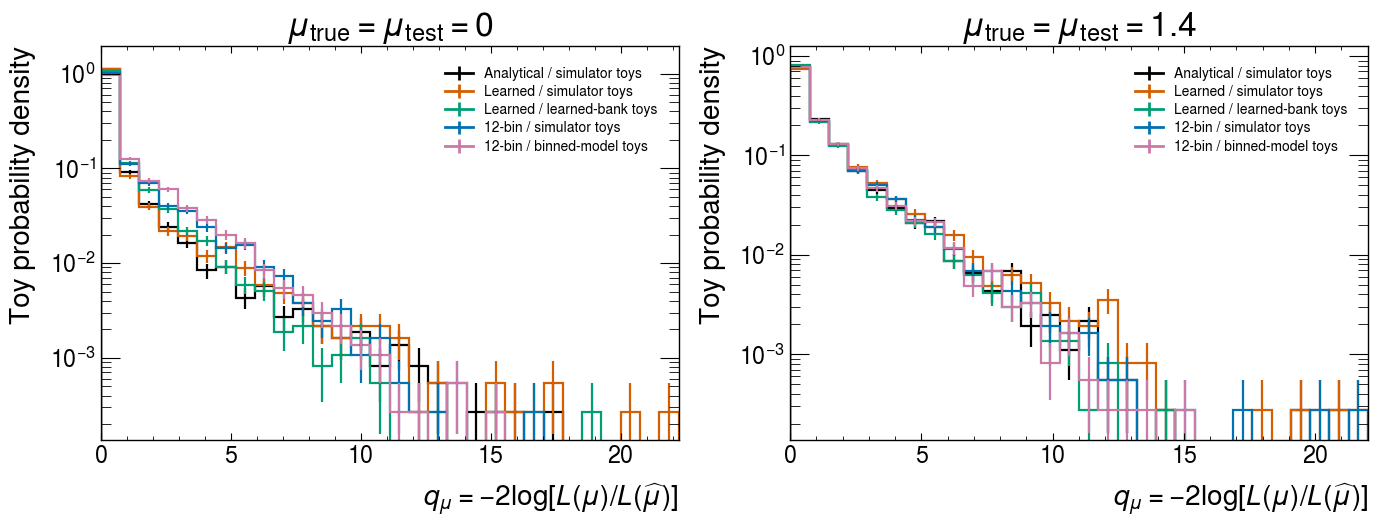

q_survival


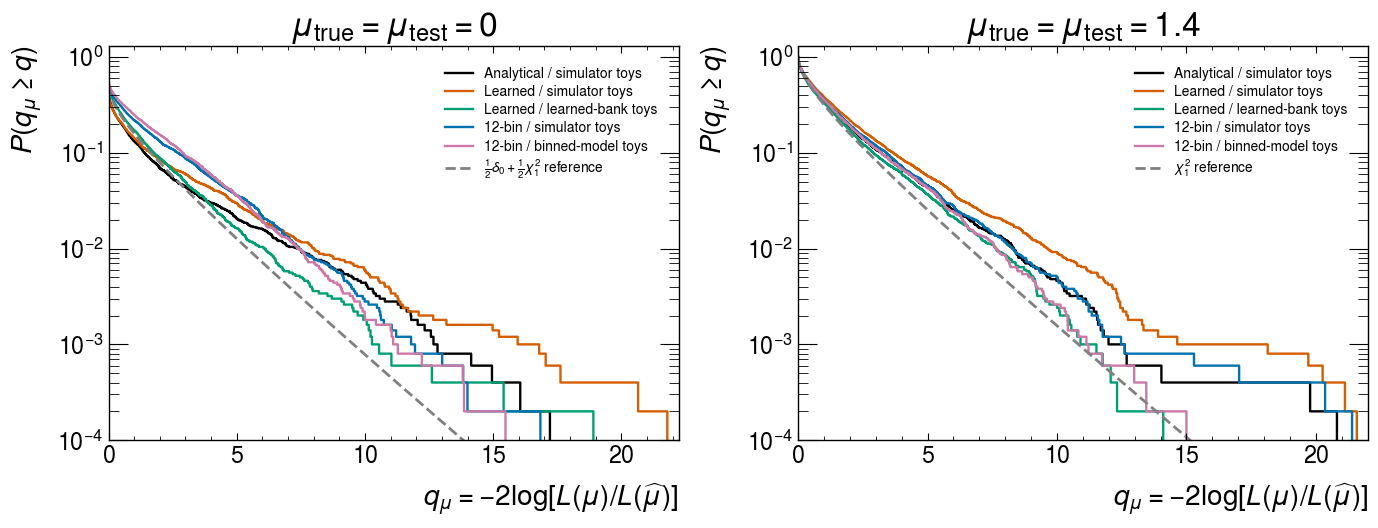

mu_hat


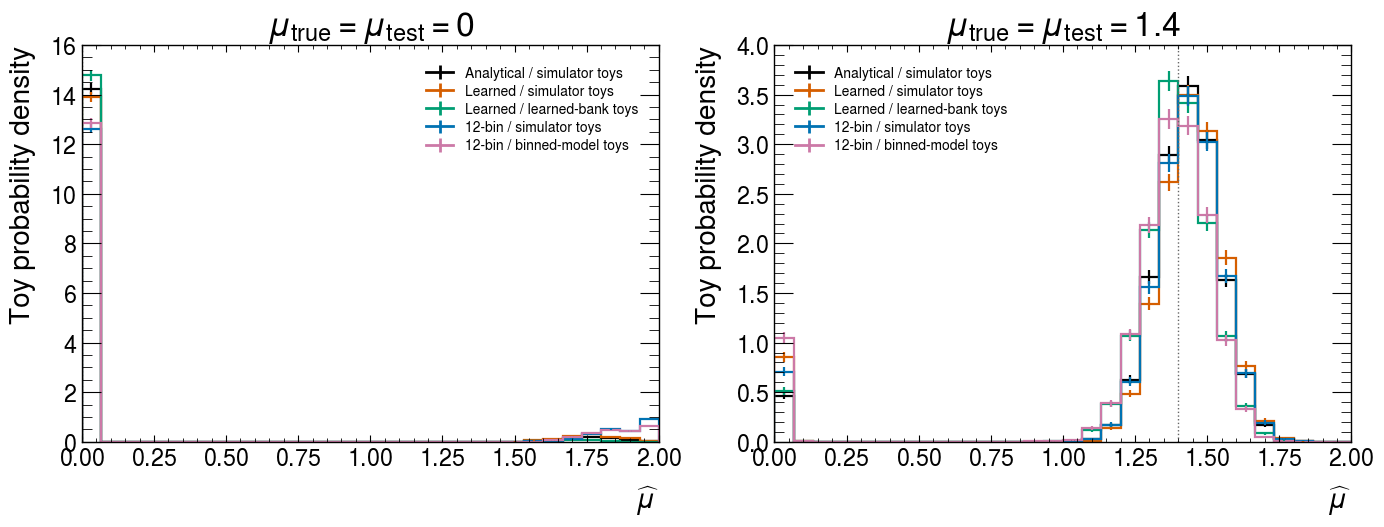

coverage


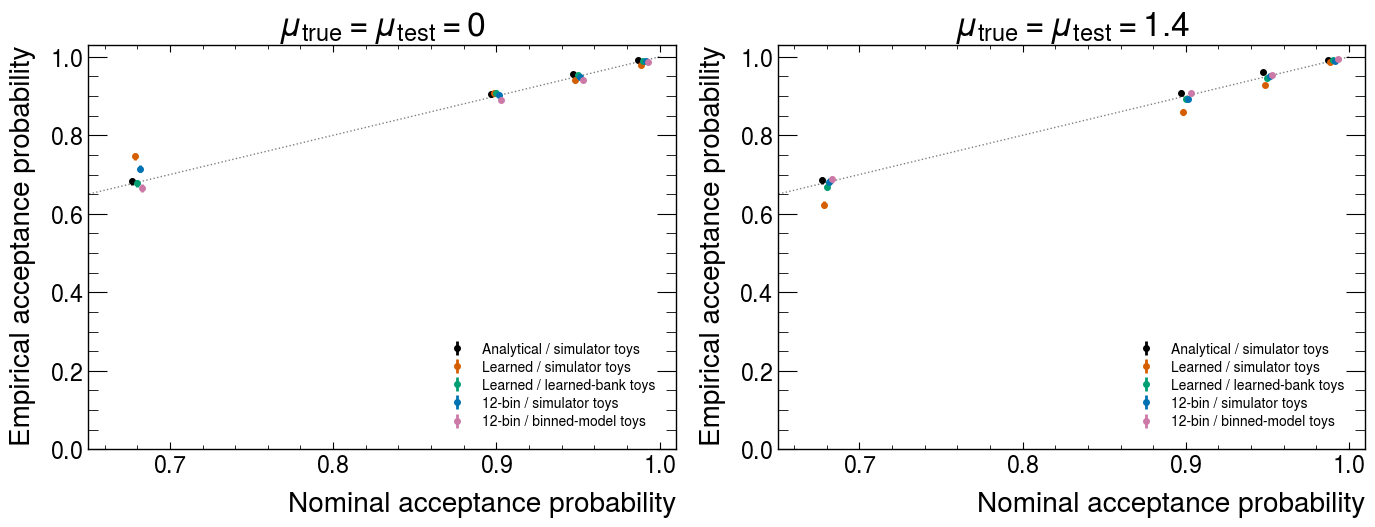

Figures: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/plots/11_test_statistic_toys/toy_study_direct
Toy records: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/results/toy_study_direct_results.csv


In [5]:
FIGURE_DIR = ROOT / "plots" / "11_test_statistic_toys" / OUTPUT_TAG
figures = plot_toy_study(toys, output=FIGURE_DIR)
for name, figure in figures.items():
    print(name)
    display(figure)
    plt.close(figure)
print("Figures:", FIGURE_DIR)
print("Toy records:", ROOT / "results" / f"{OUTPUT_TAG}_results.csv")

In [6]:
print("Empirical test-statistic and fit summaries:")
display(toys["summary"])
print("Calibration/coverage comparisons:")
display(toys["coverage"])
print("Individual toy records (first rows; complete table is saved):")
display(toys["results"].head(20))
failed = toys["results"].loc[~toys["results"]["valid"].astype(bool)]
if len(failed):
    print("Failed fits: inspect these before interpreting calibration:")
    display(failed)

Empirical test-statistic and fit summaries:


,mu_test,case,label,n_toys,n_valid,n_failed,failure_fraction,mean_q,mean_mu_hat,lower_boundary_fraction,upper_boundary_fraction,zero_q_fraction,q68,q90,q95,q99
0,0.0,analytic_simulator,Analytical / simulator toys,5000,5000,0,0.0,0.490586,0.089547,0.5664,0.0014,0.5664,0.092436,1.403850,2.692896,7.436769
1,0.0,binned_model,12-bin / binned-model toys,5000,5000,0,0.0,0.854037,0.267410,0.4258,0.0214,0.4258,0.553392,2.883828,4.341887,7.448300
2,0.0,binned_simulator,12-bin / simulator toys,5000,5000,0,0.0,0.781614,0.298486,0.4732,0.0322,0.4732,0.425793,2.694579,4.223593,7.435158
3,0.0,learned_model,Learned / learned-bank toys,5000,5000,0,0.0,0.555444,0.026356,0.4898,0.0000,0.4898,0.266977,1.764730,2.987039,6.116309
4,0.0,learned_simulator,Learned / simulator toys,5000,5000,0,0.0,0.568843,0.129899,0.5744,0.0022,0.5744,0.083232,1.639996,3.426368,8.002055
5,1.4,analytic_simulator,Analytical / simulator toys,5000,5000,0,0.0,1.176601,1.390532,0.0000,0.0000,0.0000,1.144250,3.207703,4.668587,8.325881
6,1.4,binned_model,12-bin / binned-model toys,5000,5000,0,0.0,1.170633,1.300019,0.0000,0.0000,0.0000,1.180788,3.205507,4.670816,7.664224
7,1.4,binned_simulator,12-bin / simulator toys,5000,5000,0,0.0,1.224692,1.370093,0.0000,0.0000,0.0000,1.188410,3.409789,4.801096,8.287912
8,1.4,learned_model,Learned / learned-bank toys,5000,5000,0,0.0,1.077870,1.352009,0.0000,0.0000,0.0000,1.052642,2.904976,4.383317,7.657602
9,1.4,learned_simulator,Learned / simulator toys,5000,5000,0,0.0,1.361084,1.364158,0.0002,0.0000,0.0000,1.321944,3.674284,5.434669,9.654297


Calibration/coverage comparisons:


,mu_test,case,label,nominal,calibration_case,critical_q,n_calibration,n_calibration_failed,n_evaluation,n_evaluation_failed,coverage,binomial_se,failure_lower_bound,failure_upper_bound
0,0.0,analytic_simulator,Analytical / simulator toys,0.68,analytic_simulator,0.094862,2500,0,2500,0,0.6828,0.009308,0.6828,0.6828
1,0.0,analytic_simulator,Analytical / simulator toys,0.90,analytic_simulator,1.431243,2500,0,2500,0,0.9040,0.005892,0.9040,0.9040
2,0.0,analytic_simulator,Analytical / simulator toys,0.95,analytic_simulator,2.820911,2500,0,2500,0,0.9560,0.004102,0.9560,0.9560
3,0.0,analytic_simulator,Analytical / simulator toys,0.99,analytic_simulator,7.512655,2500,0,2500,0,0.9912,0.001868,0.9912,0.9912
4,0.0,binned_model,12-bin / binned-model toys,0.68,binned_model,0.527840,2500,0,2500,0,0.6656,0.009436,0.6656,0.6656
5,0.0,binned_model,12-bin / binned-model toys,0.90,binned_model,2.813737,2500,0,2500,0,0.8900,0.006258,0.8900,0.8900
6,0.0,binned_model,12-bin / binned-model toys,0.95,binned_model,4.172051,2500,0,2500,0,0.9408,0.004720,0.9408,0.9408
7,0.0,binned_model,12-bin / binned-model toys,0.99,binned_model,7.120795,2500,0,2500,0,0.9864,0.002316,0.9864,0.9864
8,0.0,binned_simulator,12-bin / simulator toys,0.68,binned_model,0.527840,2500,0,2500,0,0.7152,0.009026,0.7152,0.7152
9,0.0,binned_simulator,12-bin / simulator toys,0.90,binned_model,2.813737,2500,0,2500,0,0.9036,0.005903,0.9036,0.9036


Individual toy records (first rows; complete table is saved):


,mu_true,mu_test,eta,toy_id,case,label,source_stream,n_observed,exposure_multiplier,template_source,mu_hat,nll,valid,message,at_lower,at_upper,n_evaluations,optimizer_failures,q
0,0.0,0.0,0.0,0,analytic_simulator,Analytical / simulator toys,0,85641,1.0,unbinned,0.000000,-0.000000,True,All resolved minima and boundaries searched,True,False,117,0,0.000000
1,0.0,0.0,0.0,0,binned_model,12-bin / binned-model toys,2,85664,1.0,direct analytical quadrature histogram (notebo...,0.000000,-0.000000,True,All resolved minima and boundaries searched,True,False,116,0,0.000000
2,0.0,0.0,0.0,0,binned_simulator,12-bin / simulator toys,0,85641,1.0,direct analytical quadrature histogram (notebo...,0.000000,-0.000000,True,All resolved minima and boundaries searched,True,False,116,0,0.000000
3,0.0,0.0,0.0,0,learned_model,Learned / learned-bank toys,1,85430,1.0,unbinned,0.000083,-0.059272,True,All resolved minima and boundaries searched,False,False,99,0,0.059272
4,0.0,0.0,0.0,0,learned_simulator,Learned / simulator toys,0,85641,1.0,unbinned,0.000000,-0.000000,True,All resolved minima and boundaries searched,True,False,118,0,0.000000
5,0.0,0.0,0.0,1,analytic_simulator,Analytical / simulator toys,0,85533,1.0,unbinned,0.000000,-0.000000,True,All resolved minima and boundaries searched,True,False,116,0,0.000000
6,0.0,0.0,0.0,1,binned_model,12-bin / binned-model toys,2,85409,1.0,direct analytical quadrature histogram (notebo...,0.003723,-2.271032,True,All resolved minima and boundaries searched,False,False,89,0,2.271032
7,0.0,0.0,0.0,1,binned_simulator,12-bin / simulator toys,0,85533,1.0,direct analytical quadrature histogram (notebo...,0.000000,-0.000000,True,All resolved minima and boundaries searched,True,False,116,0,0.000000
8,0.0,0.0,0.0,1,learned_model,Learned / learned-bank toys,1,85165,1.0,unbinned,0.000555,-0.388565,True,All resolved minima and boundaries searched,False,False,93,0,0.388565
9,0.0,0.0,0.0,1,learned_simulator,Learned / simulator toys,0,85533,1.0,unbinned,0.000000,-0.000000,True,All resolved minima and boundaries searched,True,False,120,0,0.000000


### How to interpret agreement or disagreement

- **Analytical / simulator** establishes the physical sampling
  benchmark, including boundaries and interference ambiguities.
- **Learned / simulator versus learned / learned** tests whether
  self-calibration transfers to the real toy generator.
- **Binned / simulator versus binned / binned** tests the corresponding
  transfer for the 12-bin template likelihood.
- **Binned versus unbinned** quantifies how much the economical
  histogram changes the test-statistic distribution and fitted values.

If the upper fit boundary is frequently reached, widen `MU_BOUNDS`
and use a new output tag before interpreting quantiles. If the
empirical tails remain noisy, increase `N_TOYS`. A larger ensemble
reduces toy uncertainty; it does not fix a learned-density error,
insufficient histogram resolution, or inaccurate numerical integration.